# Swath → GeoBox reprojection: `odc-geo` vs. FAISS nearest neighbour

This notebook shows two ways to turn a satellite **swath** (2-D latitude/longitude arrays + a data variable) into a regularly gridded `odc.geo.GeoBox` in a local **UTM** CRS.

* **Method 1 — `odc.geo.xr.xr_reproject`**: builds a GCP-based GeoBox from the 2-D lat/lon arrays and reprojects with `rasterio`.
* **Method 2 — FAISS nearest neighbour**: flattens the swath pixels into a 2-D (lon, lat) point cloud, builds a FAISS `IndexFlatL2`, and queries the nearest source pixel for every target grid centre.

The swath is synthetic, so the notebook runs without downloading any data.

## Install optional dependency

In [ ]:
# Only needed if faiss-cpu is not already in the environment.
# Comment out if you manage dependencies elsewhere.
# %pip install faiss-cpu

## Imports

In [1]:
import time

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pyproj
import utm
import xarray as xr
from odc.geo.crs import CRS
from odc.geo.gcp import GCPGeoBox, GCPMapping
from odc.geo.geobox import GeoBox
from odc.geo.xr import xr_coords, xr_reproject

## 1. Build a synthetic swath with 2-D lat/lon

In [2]:
np.random.seed(42)

N_ALONG = 400  # rows along track
N_ACROSS = 200  # columns across track
CENTER_LAT = 34.5
CENTER_LON = -117.5

# Base along-track line with a sinusoidal across-track scan and some curvature.
lat = (
    np.linspace(CENTER_LAT - 0.2, CENTER_LAT + 0.2, N_ALONG)[:, None]
    + np.linspace(-0.05, 0.05, N_ACROSS)[None, :]
)
lon = (
    np.linspace(CENTER_LON - 0.5, CENTER_LON + 0.5, N_ALONG)[:, None]
    + np.linspace(-0.02, 0.02, N_ACROSS)[None, :]
)

# Add a gentle curve so lats/lons are not separable.
lat += 0.01 * np.sin(np.linspace(0, 4 * np.pi, N_ALONG))[:, None]
lon += 0.01 * np.cos(np.linspace(0, 4 * np.pi, N_ALONG))[:, None]

# Synthetic data: a smooth gradient + a high-frequency pattern.
values = (lat - lat.min()) / (lat.max() - lat.min()) + 0.5 * np.sin(lon * 10)

print(f"Swath shape: {values.shape}")
print(f"Lat range:   {lat.min():.4f} → {lat.max():.4f}")
print(f"Lon range:   {lon.min():.4f} → {lon.max():.4f}")

Swath shape: (400, 200)
Lat range:   34.2500 → 34.7500
Lon range:   -118.0100 → -116.9700


## 2. Define the target UTM GeoBox

In [3]:
# UTM zone from the swath centre.
_, _, zone_number, zone_letter = utm.from_latlon(CENTER_LAT, CENTER_LON)
crs_utm = CRS(f"EPSG:326{int(zone_number):02d}")
print(f"UTM zone: {zone_number}{zone_letter} → {crs_utm}")

# Project every swath pixel to UTM to get an output bounding box.
utm_transformer = pyproj.Transformer.from_crs("EPSG:4326", crs_utm, always_xy=True)
x_utm, y_utm = utm_transformer.transform(lon, lat)

minx, maxx = float(x_utm.min()), float(x_utm.max())
miny, maxy = float(y_utm.min()), float(y_utm.max())

RESOLUTION = 250.0  # metres
dst_geobox = GeoBox.from_bbox(
    (minx, miny, maxx, maxy),
    crs=crs_utm,
    resolution=RESOLUTION,
)
print(
    f"Target GeoBox shape: {dst_geobox.shape} ({dst_geobox.shape.y} rows × {dst_geobox.shape.x} cols)"
)

UTM zone: 11S → EPSG:32611
Target GeoBox shape: Shape2d(x=383, y=221) (221 rows × 383 cols)


## 3. Method 1 — `odc-geo` reproject

In [ ]:
t0 = time.perf_counter()
# Build a GCP-based GeoBox from the 2-D lat/lon arrays.
# We sub-sample the arrays so the GCP polynomial stays small and fast.
STEP_Y, STEP_X = 20, 20
pix_rows, pix_cols = np.mgrid[0:N_ALONG:STEP_Y, 0:N_ACROSS:STEP_X]
pix = np.column_stack([pix_cols.ravel(), pix_rows.ravel()])  # (col, row) in pixel space
wld = np.column_stack(
    [lon[::STEP_Y, ::STEP_X].ravel(), lat[::STEP_Y, ::STEP_X].ravel()]
)  # (lon, lat) in WGS84

mapping = GCPMapping(pix=pix, wld=wld, crs="EPSG:4326")
src_geobox = GCPGeoBox(shape=(N_ALONG, N_ACROSS), mapping=mapping)

# Attach the GCP geobox to an xarray DataArray.  `xr_coords` creates the y/x pixel
# coordinates and the `spatial_ref` GCP coordinate that odc-geo needs.
coords = xr_coords(src_geobox, dims=("y", "x"))
coords["longitude"] = xr.DataArray(lon, dims=("y", "x"))
coords["latitude"] = xr.DataArray(lat, dims=("y", "x"))

src_da = xr.DataArray(
    values.astype("float32"),
    dims=("y", "x"),
    coords=coords,
    name="swath",
)
print(f"Source odc.geobox: {src_da.odc.geobox}")

# Reproject to the UTM GeoBox.
odc_da = xr_reproject(src_da, dst_geobox, resampling="nearest")
odc_time = time.perf_counter() - t0
print(f"odc-geo reproject took {odc_time:.3f} s")

Source odc.geobox: GCPGeoBox((200, 400), CRS('GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]'))
odc-geo reproject took 0.046 s


In [8]:
coords

{'y': <xarray.DataArray (y: 400)> Size: 2kB
 array([  0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,   7.5,   8.5,
          9.5,  10.5,  11.5,  12.5,  13.5,  14.5,  15.5,  16.5,  17.5,
         18.5,  19.5,  20.5,  21.5,  22.5,  23.5,  24.5,  25.5,  26.5,
         27.5,  28.5,  29.5,  30.5,  31.5,  32.5,  33.5,  34.5,  35.5,
         36.5,  37.5,  38.5,  39.5,  40.5,  41.5,  42.5,  43.5,  44.5,
         45.5,  46.5,  47.5,  48.5,  49.5,  50.5,  51.5,  52.5,  53.5,
         54.5,  55.5,  56.5,  57.5,  58.5,  59.5,  60.5,  61.5,  62.5,
         63.5,  64.5,  65.5,  66.5,  67.5,  68.5,  69.5,  70.5,  71.5,
         72.5,  73.5,  74.5,  75.5,  76.5,  77.5,  78.5,  79.5,  80.5,
         81.5,  82.5,  83.5,  84.5,  85.5,  86.5,  87.5,  88.5,  89.5,
         90.5,  91.5,  92.5,  93.5,  94.5,  95.5,  96.5,  97.5,  98.5,
         99.5, 100.5, 101.5, 102.5, 103.5, 104.5, 105.5, 106.5, 107.5,
        108.5, 109.5, 110.5, 111.5, 112.5, 113.5, 114.5, 115.5, 116.5,
        117.5, 118.5, 119.5, 120.

## 4. Method 2 — FAISS nearest neighbour

In [5]:
# Flatten the swath into a 2-D point cloud in (lon, lat).
src_pts = np.column_stack([lon.ravel(), lat.ravel()]).astype("float32")

# Build a brute-force L2 index.  For very large swaths replace IndexFlatL2 with
# IndexIVFFlat or IndexHNSWFlat after training on the same distribution.
index = faiss.IndexFlatL2(src_pts.shape[1])
index.add(src_pts)

# Target grid centre coordinates in UTM → transform back to lat/lon.
tgt_y = dst_geobox.coordinates["y"].values
tgt_x = dst_geobox.coordinates["x"].values
tgt_yy, tgt_xx = np.meshgrid(tgt_y, tgt_x, indexing="ij")

inv_transformer = pyproj.Transformer.from_crs(crs_utm, "EPSG:4326", always_xy=True)
tgt_lon, tgt_lat = inv_transformer.transform(tgt_xx.ravel(), tgt_yy.ravel())
tgt_pts = np.column_stack([tgt_lon, tgt_lat]).astype("float32")

# Query the nearest source pixel for every target pixel.
t0 = time.perf_counter()
distances, nearest = index.search(tgt_pts, 1)
faiss_time = time.perf_counter() - t0

# Map source values onto the target grid.
faiss_values = values.ravel()[nearest.ravel()].reshape(dst_geobox.shape.yx)
faiss_da = xr.DataArray(
    faiss_values,
    dims=("y", "x"),
    coords=xr_coords(dst_geobox),
    name="faiss_nearest",
)
print(f"FAISS nearest neighbour took {faiss_time:.3f} s")

FAISS nearest neighbour took 0.366 s


## 5. Compare results

In [6]:
valid = np.isfinite(odc_da.values) & np.isfinite(faiss_da.values)
mean_abs_diff = float(np.mean(np.abs(odc_da.values[valid] - faiss_da.values[valid])))
max_abs_diff = float(np.max(np.abs(odc_da.values[valid] - faiss_da.values[valid])))

print(f"Common valid pixels: {valid.sum():,}")
print(f"Mean absolute difference: {mean_abs_diff:.4f}")
print(f"Max absolute difference:  {max_abs_diff:.4f}")
print(f"odc-geo time: {odc_time:.3f} s")
print(f"FAISS time:   {faiss_time:.3f} s")

Common valid pixels: 15,028
Mean absolute difference: 0.0724
Max absolute difference:  0.2437
odc-geo time: 0.046 s
FAISS time:   0.366 s


## 6. Visualise

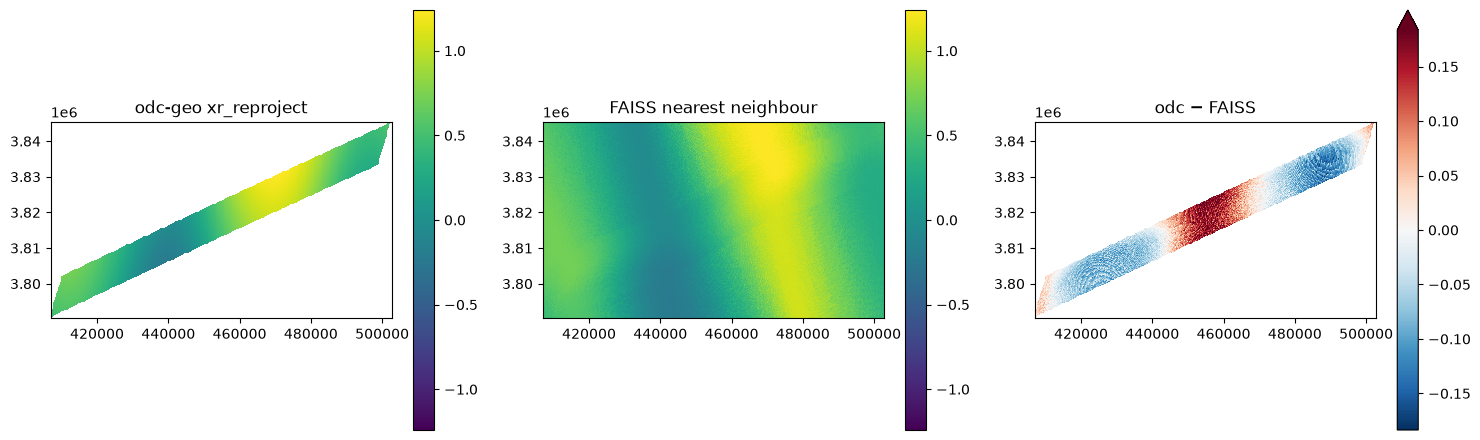

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

odc_da.plot(ax=axes[0], cmap="viridis", add_labels=False)
axes[0].set_title("odc-geo xr_reproject")

faiss_da.plot(ax=axes[1], cmap="viridis", add_labels=False)
axes[1].set_title("FAISS nearest neighbour")

diff = xr.DataArray(
    np.where(valid, odc_da.values - faiss_da.values, np.nan),
    dims=("y", "x"),
    coords=xr_coords(dst_geobox),
    name="difference",
)
diff.plot(ax=axes[2], cmap="RdBu_r", robust=True, add_labels=False)
axes[2].set_title("odc − FAISS")

for ax in axes:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Take-aways

* `odc-geo` with a `GCPGeoBox` handles the reprojection for you and gives access to all of `rasterio`'s resampling methods (bilinear, cubic, average, etc.). It is the simplest route when the source is a 2-D lat/lon swath.
* FAISS nearest neighbour is useful when you want full control over the distance metric, need an exact NN remap, or want to accelerate huge point clouds on GPU (`faiss-gpu`). The brute-force `IndexFlatL2` used here is exact but can be replaced by faster approximate indices for production-size swaths.
* The small differences between the two outputs come from different coordinate handling: `odc-geo`/`rasterio` maps pixels through the GCP polynomial, while FAISS directly searches the flattened source points in (lon, lat) space.